# Homework Chapters 10 and 11

Numbers correspond to homework problems from [Introduction to Computational Physics](https://www.amazon.com/Introduction-Computational-Physics-Differential-Simulations/dp/B0FL7W88TM)

## Chapter 10


76. Solve $x^4−10x^2+x+7=0$, find the algebraic solutions and evaluate them with 20 digits of precision. Are the solutions real or complex?

In [32]:
from sympy import *
import numpy as np
import matplotlib.pyplot as plt
init_printing()

In [33]:
# define symbolic equation
x = symbols("x")
f = x**4 - 10*x**2 + x + 7
print("Solve:")
Eq(f,0)

Solve:


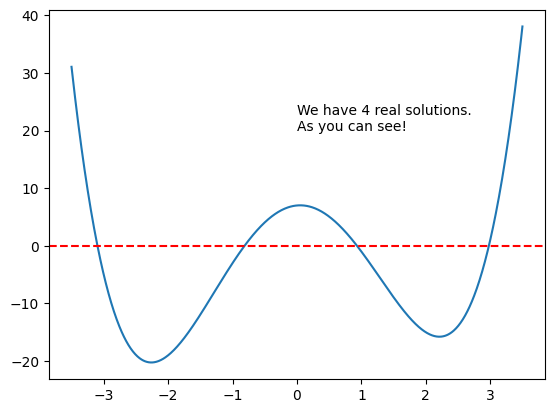

In [34]:
f_num = lambdify(x,f)
x_vec = np.linspace(-3.5,3.5,1000)
fig, ax = plt.subplots()
ax.plot(x_vec,f_num(x_vec))
ax.axhline(0, color='red',ls="--")
ax.text(0, 20, "We have 4 real solutions.\nAs you can see!")
plt.show()

In [35]:
# double-check
from scipy.optimize import fsolve
fsolve(f_num, [-3,-1,1,3])

array([-3.09728561, -0.81393873,  0.93201858,  2.97920576])

In [36]:
# Solution 76 (algebraic)
sols = solve(f,x)
n=0
for sol in sols:
  n=n+1
  if im(sol)==0:
    print(f"Solution {n} is real.")
  else:
    print(f"Solution {n} has imaginary part.")

Solution 1 is real.
Solution 2 is real.
Solution 3 is real.
Solution 4 is real.


In [37]:
# Solution 76 (numerical)
n=0
for sol in sols:
  n=n+1
  if im(sol)==0:
    x0 = re(sol.n(20))
    print(f"Solution {n} is {x0}")
  else:
    print("Solution has imaginary part.")

Solution 1 is -3.0972856116664024849
Solution 2 is 0.93201858464114261960
Solution 3 is 2.9792057568619831523
Solution 4 is -0.81393872983672328700


79. Use the `limit()` function to evaluate $\lim_{x \to 0} \frac{\sin x}{x}$

In [38]:
# Solution 79 (limit)
f = sin(x)/x
print(f"The limit for {f=} for x->0 is:")
limit(f, x,0)

The limit for f=sin(x)/x for x->0 is:


83. Find the number of 1s in the first 1000 digits of $\pi$.

In [39]:
# Solution 83
s = str(pi.n(1000))
n=0
for d in s[2:]: # skip "3."
  if int(d)==1:
    n=n+1
print(f"There are {n} digits of 1 in the first 1000 digits of pi.")

There are 116 digits of 1 in the first 1000 digits of pi.


92. Take $f(x) = \frac{d}{dx} \left[ \left( 1-\frac{1}{x} \right)^x \right]$, then  **(a)**  compute $\lim_{x \to +1} f(x)$, **(b)**  graph the function $f(x)$ near $x=1$.

In [40]:
# Solution 92 a (limit)
# help(limit) => dir="+"
f = (1-1/x)**x
df = f.diff(x)
limit(df, x, 1, dir="+")

<lambdifygenerated-13>:2: RuntimeWarning: invalid value encountered in power
  return (1 - 1/x)**x*(log(1 - 1/x) + 1/(x*(1 - 1/x)))
<lambdifygenerated-13>:2: RuntimeWarning: invalid value encountered in log
  return (1 - 1/x)**x*(log(1 - 1/x) + 1/(x*(1 - 1/x)))


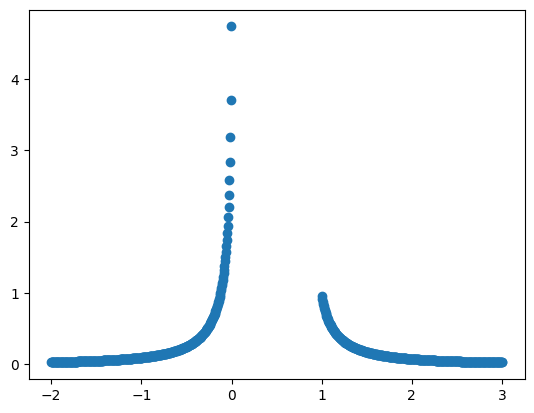

In [41]:
# Solution 92 b (graph)
fig, ax = plt.subplots()
x_vec = np.linspace(-2,3, 1000)
f_num = lambdify(x,df)
ax.scatter(x_vec, f_num(x_vec))
plt.show()

95. **(P)** Use SymPy to demonstrate the following identity, which is commonly encountered in quantum mechanics: $\int_{-\infty}^{\infty}  y^2 e^{-\frac{(y-y_0)^2}{\sigma}} \; dy = \sqrt{\pi \sigma}\left(\frac{\sigma}{2} + y_0^2 \right)$.

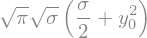

In [42]:
# Solution 95
y, y0 = symbols("y y0")
s = symbols("sigma", positive=True) # this identity assumes that sigma is positive
f = y**2 * exp(-(y-y0)**2/s)
integrate(f, (y,-oo,oo)).simplify()

## Chapter 11

98. Taylor expand the function $\ln(1+x)$ to order 4 and discuss some of the assumptions.

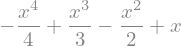

In [43]:
# Solution 98
f = log(1+x)
series(f, x, 0, n=5).removeO()

100. Given the function $f=x^4 - 2x^2\sin(x)$. Calculate the derivative symbolically, then graph the derivative using `lambdify()`.

In [44]:
# Solution 100
f = x**4 - 2*x**2*sin(x)
df = f.diff(x)
df

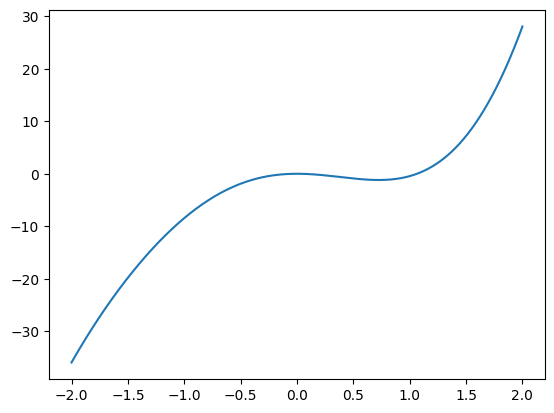

In [45]:
fig, ax = plt.subplots()
x_vec = np.linspace(-2,2,1000)
f_num = lambdify(x,df)
ax.plot(x_vec, f_num(x_vec))
plt.show()

102. **(P)** A.Y. Kamenshchik et al. consider the long-wavelength correlation functions of massive scalar fields in *de Sitter spacetime* in *"Massive scalar field in de Sitter spacetime:
a two-loop calculation and a comparison with the
stochastic approach"*. Show that the first-part of [Equation 22](https://arxiv.org/pdf/2109.05625), $\int_0^\infty \frac{\sin w}{w^{2-2u}} dw$ for $0 < u < 1$ is equal to $-\cos(\pi u) \Gamma(2u-1)$ and Taylor expand this function for small values of $u$ to 3 terms, see also <https://arxiv.org/pdf/2109.05625>.

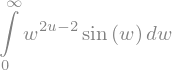

In [46]:
# Solution 102
w, u = symbols("w u", real=True)
f = sin(w)/(w**(2-2*u))
Integral(f,(w,0,oo))

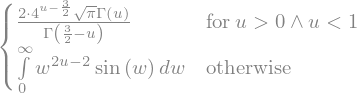

In [47]:
integrate(f,(w,0,oo))

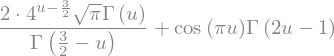

In [48]:
# let us choose the ansewr for 0<u<1, since u is positive.
sol = integrate(f,(w,0,oo)).args[0].args[0]
should_be_zero = sol + cos(pi*u)*gamma(2*u-1)
should_be_zero

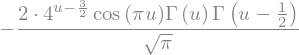

In [49]:
expr = sol.replace(
    lambda e: e.is_Pow and e.base == gamma(Rational(3,2) - u) and e.exp == -1,
    lambda e: -(cos(pi*u)/pi) * gamma(u - Rational(1,2))
)
expr

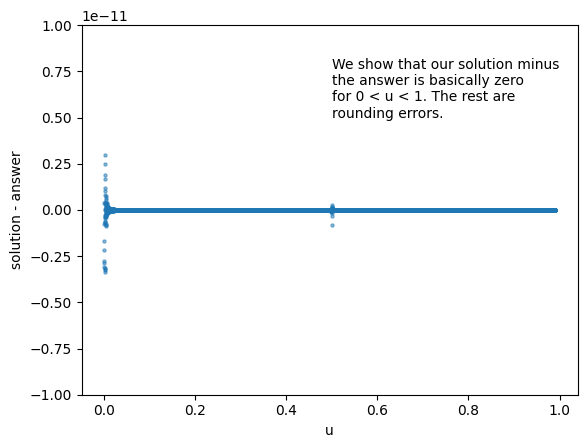

In [50]:
fig, ax = plt.subplots()
f_num = lambdify(u, should_be_zero)
x_vec = np.linspace(0.001,0.99,10000)
ax.scatter(x_vec, f_num(x_vec), alpha=0.5, s=5)
ax.set_ylim(-1e-12, 1e-12)
ax.text(0.5,0.5e-11, s="We show that our solution minus\nthe answer is basically zero\nfor 0 < u < 1. The rest are\nrounding errors.")
ax.set_xlabel("u"); ax.set_ylabel("solution - answer")
ax.set_ylim((-1e-11,1e-11))
plt.show()

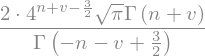

In [51]:
n = symbols("n", integer=True)
v = symbols("v", positive=True)
gammasimp(sol.subs(u,v+n))

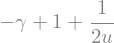

In [52]:
# Taylor expansion for the leading term from the paper: 1/(2u):
series(sol, u, 0, n=1).removeO().simplify()

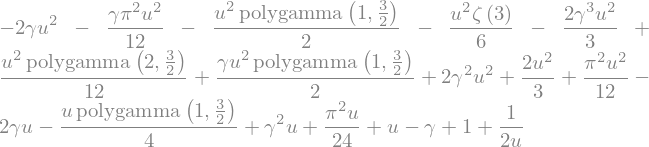

In [53]:
# and now for additional terms
series(sol, u, 0, n=3).removeO().simplify()

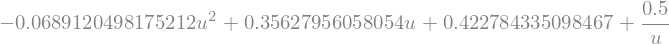

In [54]:
# and now for additional terms
series(sol, u, 0, n=3).removeO().simplify().evalf()